# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

# Your Phase 1 solution to the problem goes here.
![Q1 Proofs Work](Images/DS 3001 Scan.png)


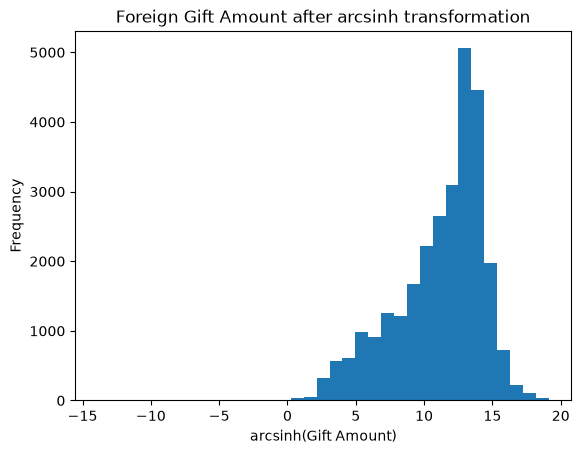

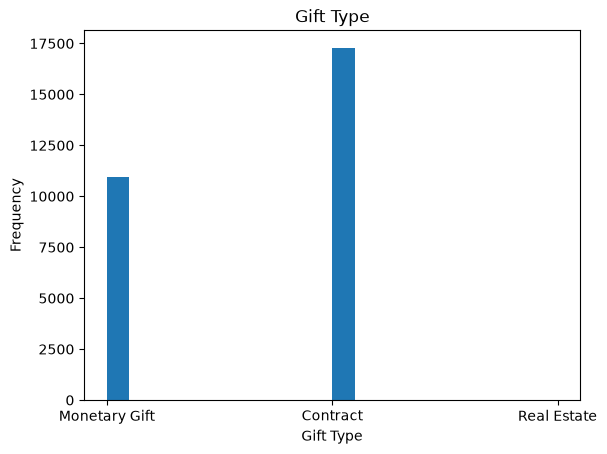

0.6120973742957372
0.3875128450444704
0.00038978065979235324


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


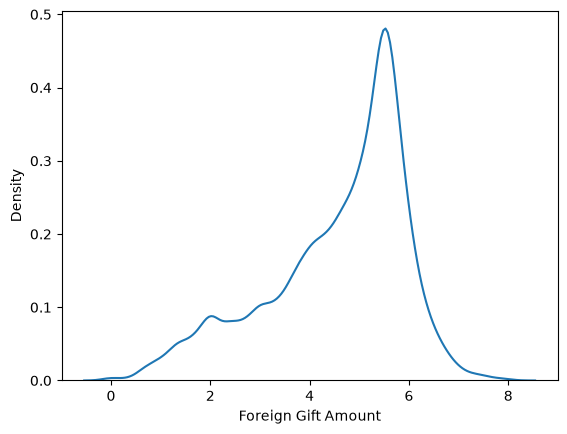

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


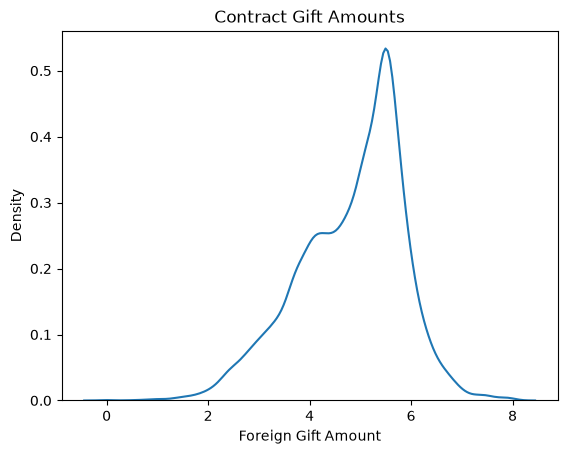

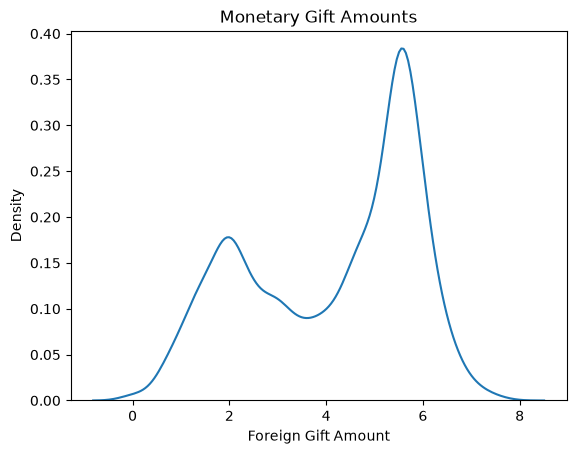

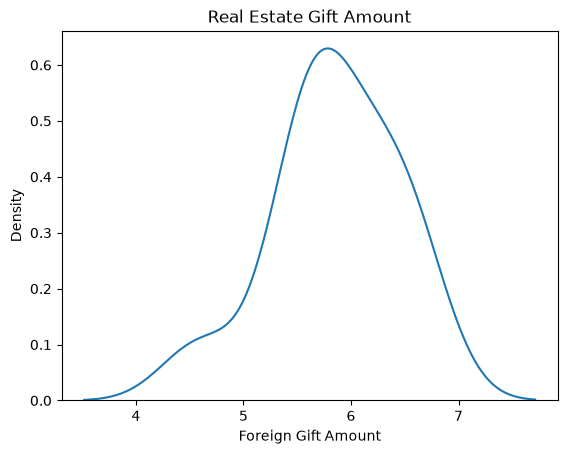

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Sanofi-Aventis Recerche                  62106706
Saudi Arabia                             59450098
Sanofi-Aventis Recherche                 58520202
Skolkovo Foundation                      51500000
Stavros S. Niarchos Foundation        

In [52]:
#Q2:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('./data/ForeignGifts_edu.csv')
df["gift_amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])

df["gift_amount_arcsinh"].hist(bins=35, grid=False)
plt.title("Foreign Gift Amount after arcsinh transformation")
plt.xlabel("arcsinh(Gift Amount)")
plt.ylabel("Frequency")
plt.show()


df["Gift Type"].hist(bins=20, grid=False)
plt.title("Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Frequency")
plt.show()

df["Gift Type"].value_counts()
contract_prop = 17274/(17274+10936+11)
monetary_gift_prop = 10936/(17274+10936+11)
real_estate_prop = 11/(17274+10936+11)
print(contract_prop)
print(monetary_gift_prop)
print(real_estate_prop)

sns.kdeplot(np.log10(df['Foreign Gift Amount']))
plt.show()

sns.kdeplot(np.log10(df[df["Gift Type"] == "Contract"]["Foreign Gift Amount"]))
plt.title("Contract Gift Amounts")
plt.show()
sns.kdeplot(np.log10(df[df["Gift Type"] == "Monetary Gift"]["Foreign Gift Amount"]))
plt.title("Monetary Gift Amounts")
plt.show()
sns.kdeplot(np.log10(df[df["Gift Type"] == "Real Estate"]["Foreign Gift Amount"]))
plt.title("Real Estate Gift Amount")
plt.show()

df["Country of Giftor"].value_counts().head(50)
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(50)

df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(20)


Q2 #2: The graph shows gift amounts ranged from 0 - 10's of millions of dollars. While the exact amount isn't directly labeled on the graph, we can see that the majority of donations are around 200k (or at least in the 100's of thousands). Then, there is a steep dropoff as donation amounts get larger.

Q2 #3: The proportion of gifts that are contracts is 0.6121. The proportion of gifts that are monetary gifts is 0.3875. The proportion of gifts that is real estate is 0.0004.

Q2 #4: When looking at the respective graphs foreign gift amounts relative to each gift type, I noticed that the density correlated to gifts peaked for all gift types at amounts around log(x) = 5.5, or x roughly equalling $300,000.

Q2 #5: The top 15 countries in order of most gifts gifted are: England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, (South) Korea, Hong Kong, Qatar, The Netherlands, India, Taiwan, Israel. The top 15 countries in order of the most money gifted are: Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Swtzerland, India, Germany, United Arab Emirates, France, Singapore, (South) Korea.

Q2 #6: The giftors that gifted the most money are: Qatar Foundation/Qatar Foundation for Education, Saudi Arabian Cultural Mission, and Anonymous donors (though we cannot determine the number of different donors if they are all under "Anonymous").


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** b6cf25e93b45ff6bdf36143c375828ec052a9f0e
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]